#### The goal of this project is to segment customers based on their purchasing behaviour and demographic information

### Unsupervised learning- clustering using kmeans

In [47]:
# import required libraries

# Data Analysis libraries
import pandas as pd
import numpy as np

# Data visualization
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter

# machine learning and Evaluation
!pip install scikit-learn
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import silhouette_score, homogeneity_score

import warnings
warnings.filterwarnings("ignore")

Defaulting to user installation because normal site-packages is not writeable


In [17]:
# load data
data = pd.read_csv(r"C:\Users\USER\Downloads\Customers.csv")
data.head(3)

,CustomerID,Genre,Age,Annual_Income_(k$),Spending_Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6


In [19]:
data.rename(columns={'Genre':'Gender'},inplace=True)
data.head(3)

,CustomerID,Gender,Age,Annual_Income_(k$),Spending_Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6


In [20]:
data.shape

(200, 5)

In [21]:
data.describe()

,CustomerID,Age,Annual_Income_(k$),Spending_Score
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [23]:
data.info();

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   CustomerID          200 non-null    int64 
 1   Gender              200 non-null    object
 2   Age                 200 non-null    int64 
 3   Annual_Income_(k$)  200 non-null    int64 
 4   Spending_Score      200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [24]:
# checking for null values
print(data.isnull().sum())

CustomerID            0
Gender                0
Age                   0
Annual_Income_(k$)    0
Spending_Score        0
dtype: int64


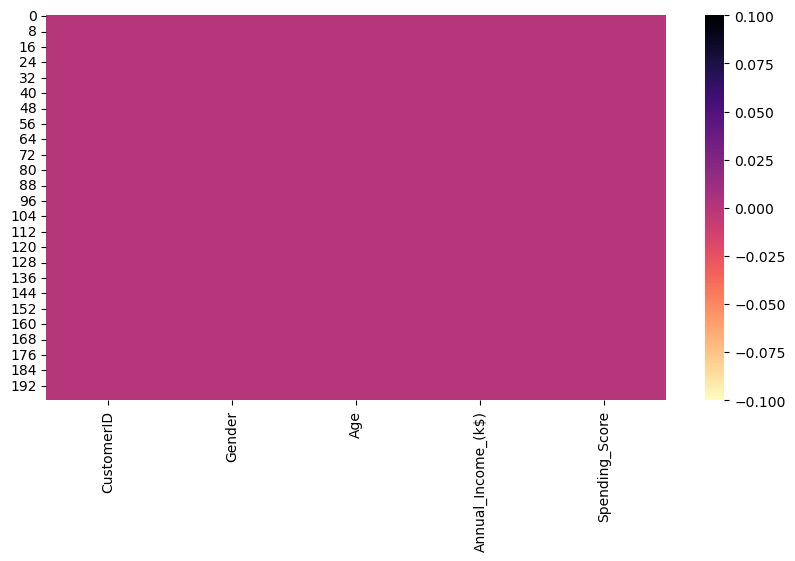

In [27]:
# visualizing missing data (if any)
plt.figure(figsize=(10,5))
sns.heatmap(data.isnull(),cbar=True, cmap="magma_r");

### DATA CLEANING AND PRE-PROCESSING

In [28]:
# Checking for duplicates
print(data.duplicated().sum())

0


### EXPLORATORY DATA ANALYSIS

In [34]:
data.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual_Income_(k$)', 'Spending_Score'], dtype='object')

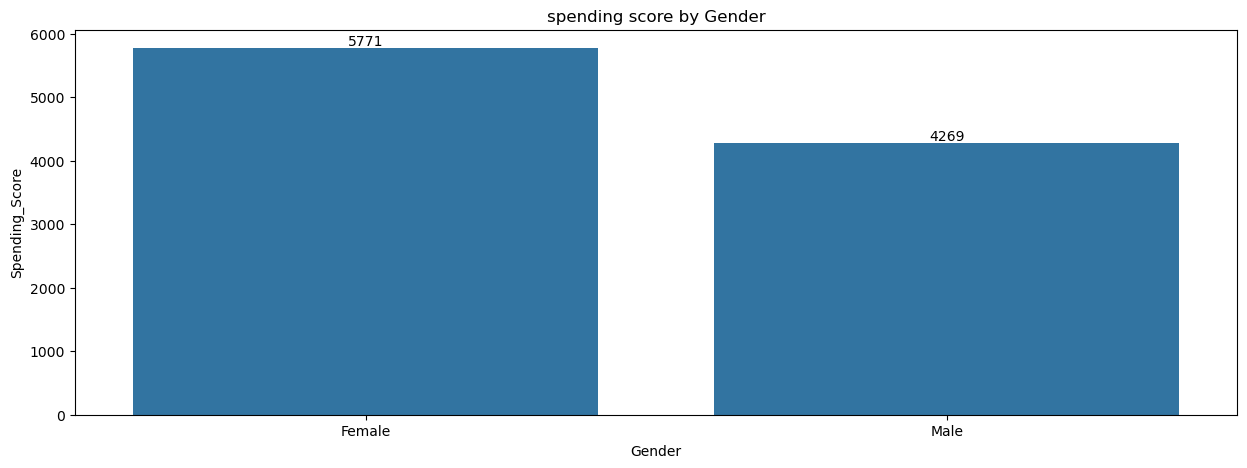

In [46]:
# checking Gender and spending_score
plt.figure(figsize=(15,5))
gender_spendingscore = data.groupby('Gender')["Spending_Score"].sum().reset_index()
values=gender_spendingscore['Spending_Score']
ax=sns.barplot(x='Gender',data=gender_spendingscore,y='Spending_Score')
ax.bar_label(container=ax.containers[0],labels=values)
plt.title("spending score by Gender");


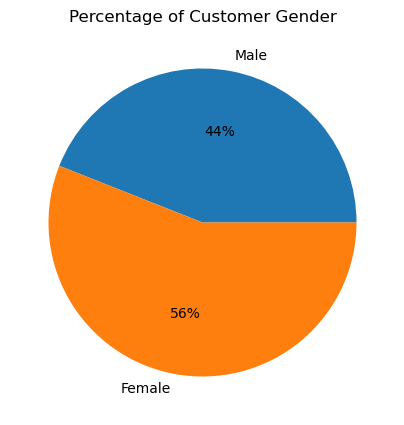

In [50]:
# Total numbers of male and female
fig,ax =plt.subplots(figsize=(5,5))
count = Counter(data["Gender"])
ax.pie(count.values(),labels=count.keys(),autopct=lambda p:f'{p:.0f}%')
ax.set_title("Percentage of Customer Gender")
plt.show()

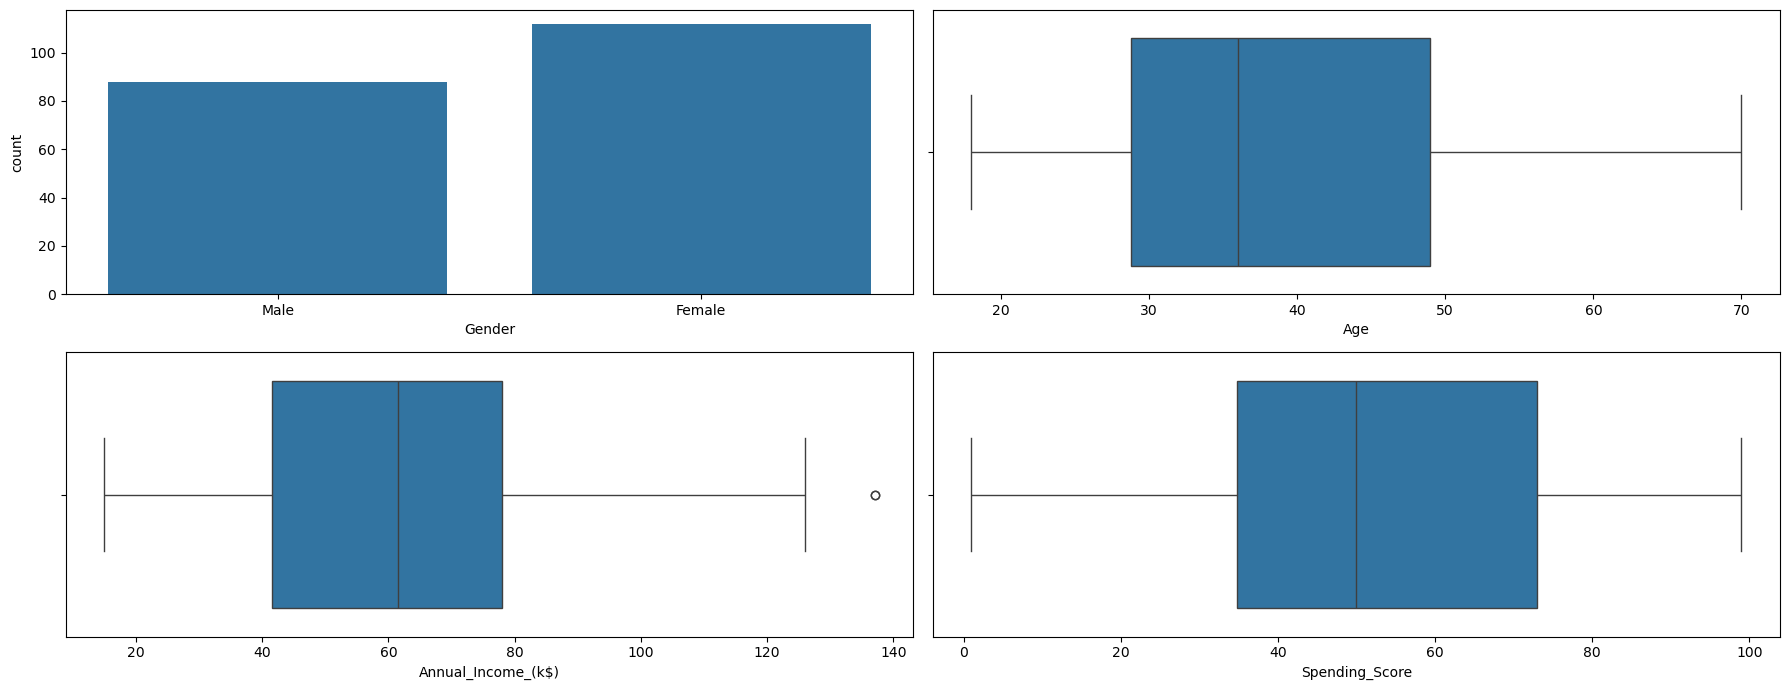

In [52]:
# Exploratory data analysis in a boxplot

fig,axs = plt.subplots(2,2, figsize=(18,7))
plt1 = sns.countplot(x=data['Gender'],ax = axs[0,0])
plt2 = sns.boxplot(x=data['Age'],ax = axs[0,1])
plt3 = sns.boxplot(x=data['Annual_Income_(k$)'], ax = axs[1,0])
plt4 = sns.boxplot(x=data['Spending_Score'], ax = axs[1,1])

plt.tight_layout()



In [53]:
data.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual_Income_(k$)', 'Spending_Score'], dtype='object')

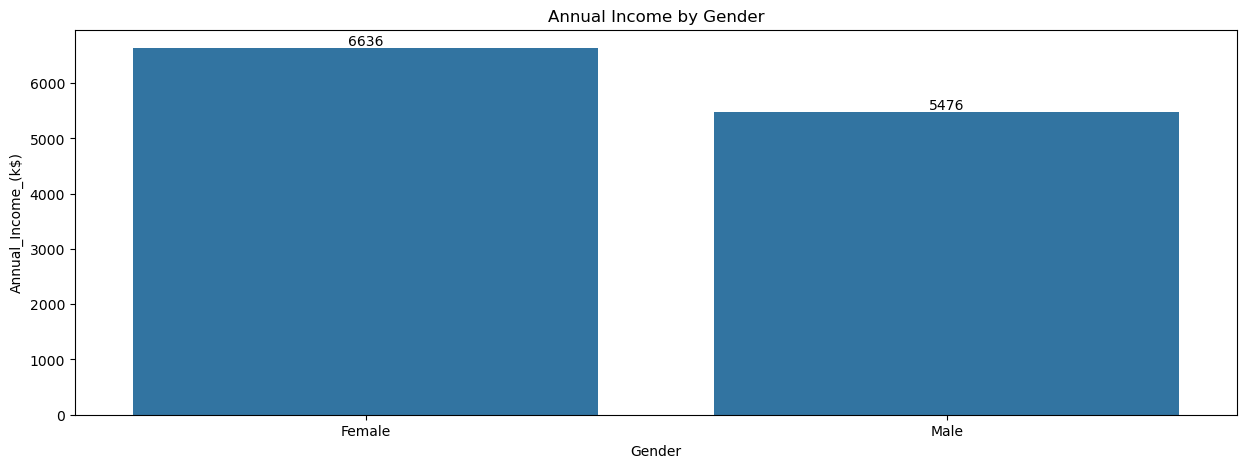

In [55]:
# checking Gender and Annual_Income_(k$)
plt.figure(figsize=(15,5))
gender_Annual_income = data.groupby('Gender')["Annual_Income_(k$)"].sum().reset_index()
values=gender_Annual_income['Annual_Income_(k$)']
ax=sns.barplot(x='Gender',data=gender_Annual_income,y='Annual_Income_(k$)')
ax.bar_label(container=ax.containers[0],labels=values)
plt.title("Annual Income by Gender");

In [57]:
from sklearn.preprocessing import LabelEncoder

#Label Encoding
encoder = LabelEncoder()

# looping for columns
for j in data.columns[1:]:
    if (data[j].dtype=='object'):
        data[j] = encoder.fit_transform(data[j])
    else:
        data[j] = data[j]

data.head()

,CustomerID,Gender,Age,Annual_Income_(k$),Spending_Score
0,1,1,19,15,39
1,2,1,21,15,81
2,3,0,20,16,6
3,4,0,23,16,77
4,5,0,31,17,40


In [58]:
# Removing CustomerID column
data.drop('CustomerID',axis=1, inplace=True)
data.head(3)


,Gender,Age,Annual_Income_(k$),Spending_Score
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6


#### Determine the optimal number of clusters

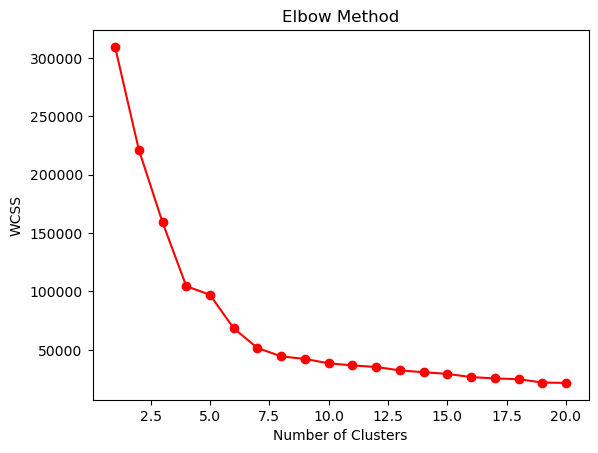

In [73]:
wcss = []
for i in range(1,21):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(data)
    wcss.append(kmeans.inertia_)
plt.plot(range(1,21), wcss, color='red', marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()
        

In [74]:
# Fit k-means clustering model
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
kmeans.fit(data)

# Add cluster labels to data
data['cluster'] = kmeans.labels_

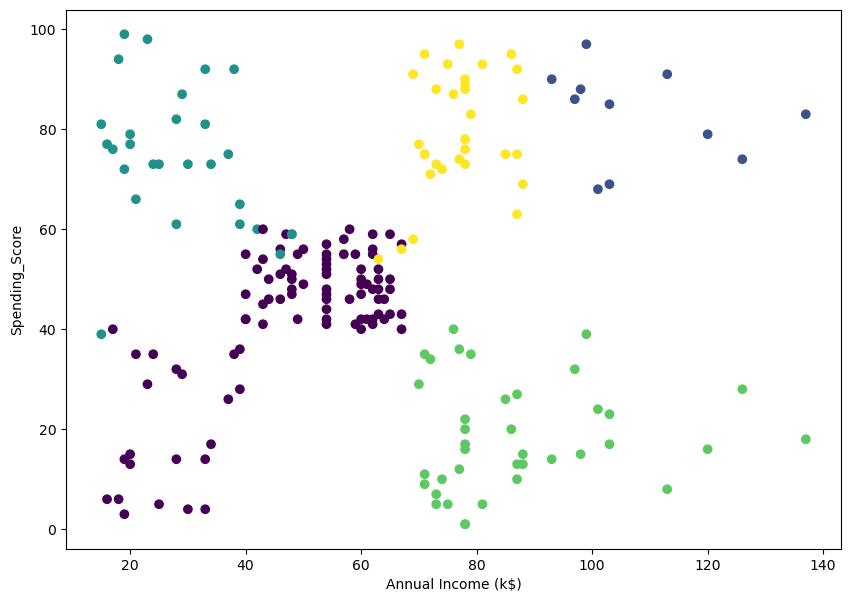

0.36431459921169224

In [78]:
# Visualizd cluster results
plt.figure(figsize=(10,7))
plt.scatter(data['Annual_Income_(k$)'],data['Spending_Score'],c=data['cluster'],label='centroids')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending_Score')
plt.show()

# calculate silhouette score
from sklearn.metrics import silhouette_score

silhouette_score(data,kmeans.labels_)

##### Narration: We used K_Means to group customers into 5 clusters based on their Annual income and how much they spend, the points with similar income and spending habits are colored together e.g some customers with low income and low spending, customers with low income and high spending score,customers with high income and low spending score etc.
##### The silhouette score is how tight each group is and how seperate they are from other groups. Our score came out 0.36 which tells us that the clustering is not very strong as it is closer to 0 than to 1